# AirPulse AI – Pollution Hotspot Detection Notebook
## Geospatial Risk Clustering (K-Means & DBSCAN)

### Step 1: Imports & Setup

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

print('✅ Imports complete for Hotspot Clustering!')

✅ Imports complete for Hotspot Clustering!


### Step 2: Load Data & Generate Spatial Coordinates

In [2]:
np.random.seed(42)
sample_locations = [
    {'lat': 23.23, 'lng': 77.43, 'base_aqi': 285}, # MP Nagar
    {'lat': 23.28, 'lng': 77.45, 'base_aqi': 312}, # Industrial Area
    {'lat': 28.65, 'lng': 77.31, 'base_aqi': 342}, # Anand Vihar
    {'lat': 22.75, 'lng': 75.89, 'base_aqi': 185}  # Vijay Nagar
]

records = []
for loc in sample_locations:
    for _ in range(50):
        lat = loc['lat'] + np.random.normal(0, 0.02)
        lng = loc['lng'] + np.random.normal(0, 0.02)
        aqi = loc['base_aqi'] + np.random.normal(0, 15)
        records.append([lat, lng, aqi])

df_hotspots = pd.DataFrame(records, columns=['lat', 'lng', 'aqi'])
df_hotspots.head()

,lat,lng,aqi
0,23.239934,77.427235,294.715328
1,23.260461,77.425317,281.487946
2,23.261584,77.445349,277.957884
3,23.240851,77.420732,278.014054
4,23.234839,77.391734,259.126233


### Step 3: Model Training (K-Means & Silhouette Evaluation)

In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_hotspots['cluster'] = kmeans.fit_predict(df_hotspots[['lat', 'lng', 'aqi']])
sil_score = silhouette_score(df_hotspots[['lat', 'lng', 'aqi']], df_hotspots['cluster'])
print(f'✅ K-Means Clustering Silhouette Score: {sil_score:.4f}')

✅ K-Means Clustering Silhouette Score: 0.6239


### Step 4: Visualize Hotspot Clusters

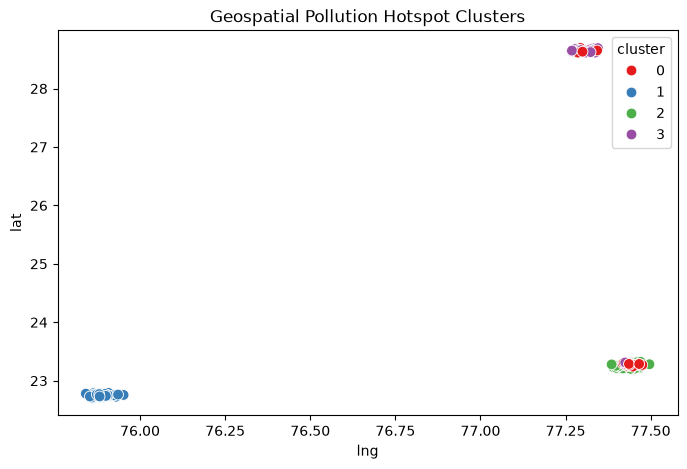

In [4]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_hotspots, x='lng', y='lat', hue='cluster', palette='Set1', s=60)
plt.title('Geospatial Pollution Hotspot Clusters')
plt.show()

### Step 5: Save Model & Export Artifacts

In [5]:
os.makedirs('../models', exist_ok=True)
joblib.dump(kmeans, '../models/hotspot_model.pkl')
print('✅ Hotspot model saved to models/hotspot_model.pkl')

✅ Hotspot model saved to models/hotspot_model.pkl
